In [2]:
import pandas as pd 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df =pd.read_csv('AB_NYC_2019_cleaned.csv')

In [4]:
df.head()

,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,price_per_night,days_since_last_review
0,Clean & quiet apt home by the park,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365,149.0,262.0
1,Skylit Midtown Castle,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355,225.0,48.0
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365,50.0,0.0
3,Cozy Entire Floor of Brownstone,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194,89.0,3.0
4,Entire Apt: Spacious Studio/Loft by central park,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0,8.0,231.0


In [21]:
df.columns

Index(['name', 'host_id', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'calculated_host_listings_count',
       'availability_365', 'price_per_night', 'days_since_last_review'],
      dtype='str')

In [23]:
df[[ 'minimum_nights',
       'number_of_reviews', 'calculated_host_listings_count',
       'availability_365', 'price_per_night', 'days_since_last_review']].describe()

,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,price_per_night,days_since_last_review
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,7.029962,23.274466,7.143982,112.781327,70.174247,219.994151
std,20.510550,44.550582,32.952519,131.622289,157.620388,385.524720
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,0.000000,20.000000,4.000000
50%,3.000000,5.000000,1.000000,45.000000,44.500000,24.000000
75%,5.000000,24.000000,2.000000,227.000000,81.500000,246.000000
max,1250.000000,629.000000,327.000000,365.000000,8000.000000,3024.000000


### univariate analysis :

In [5]:
df.columns 

Index(['name', 'host_id', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'calculated_host_listings_count',
       'availability_365', 'price_per_night', 'days_since_last_review'],
      dtype='str')

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


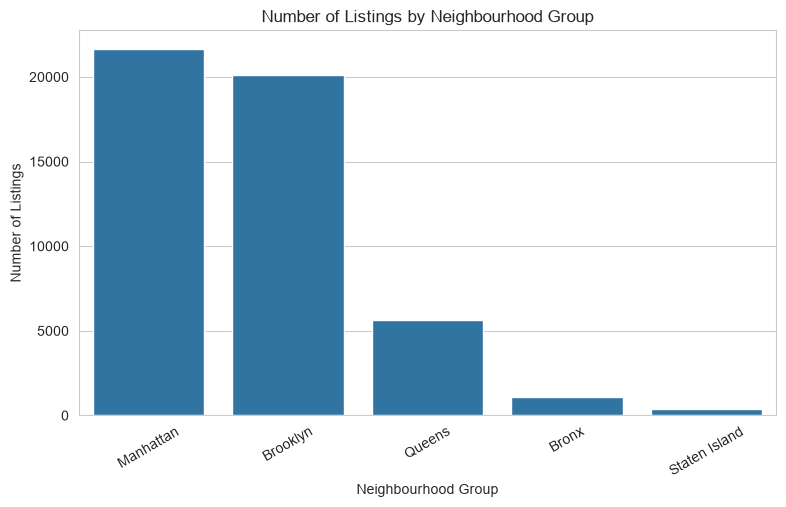

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


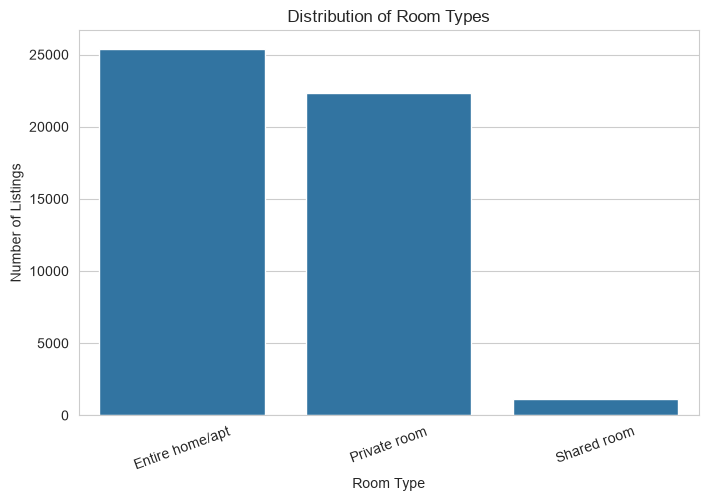

count    48895.000000
mean        70.174247
std        157.620388
min          0.000000
25%         20.000000
50%         44.500000
75%         81.500000
max       8000.000000
Name: price_per_night, dtype: float64


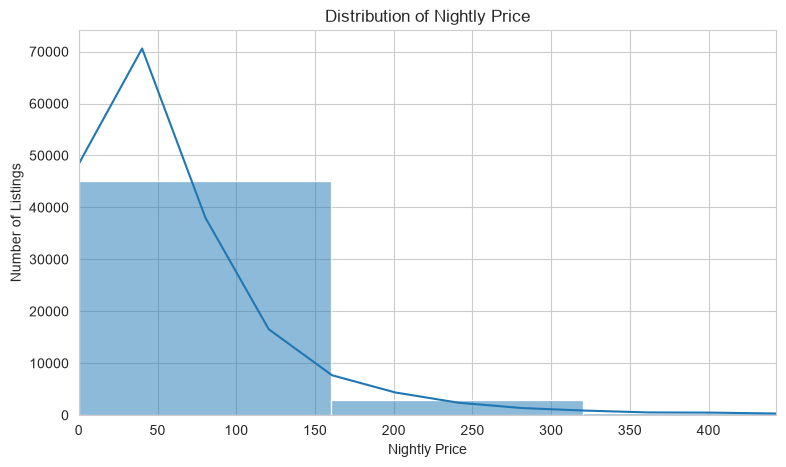

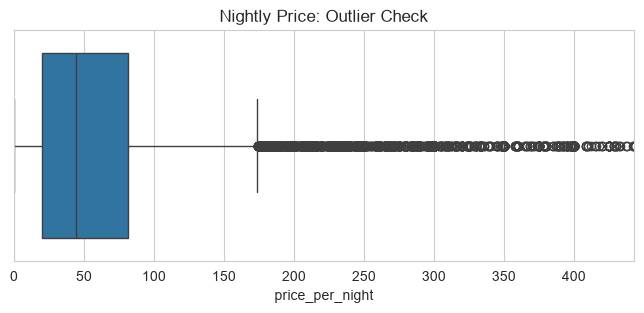

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64


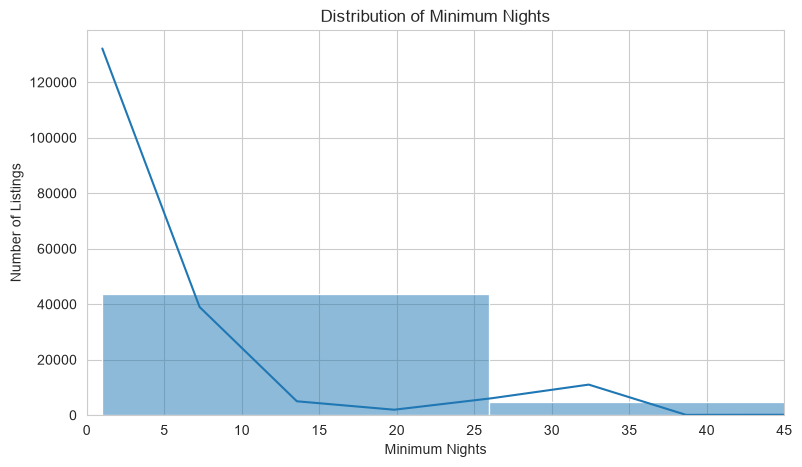

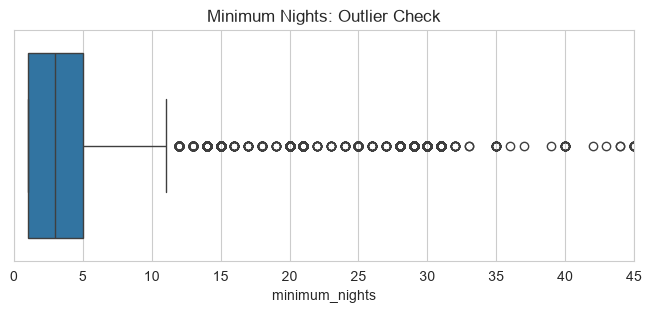

count    48895.000000
mean         7.143982
std         32.952519
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64


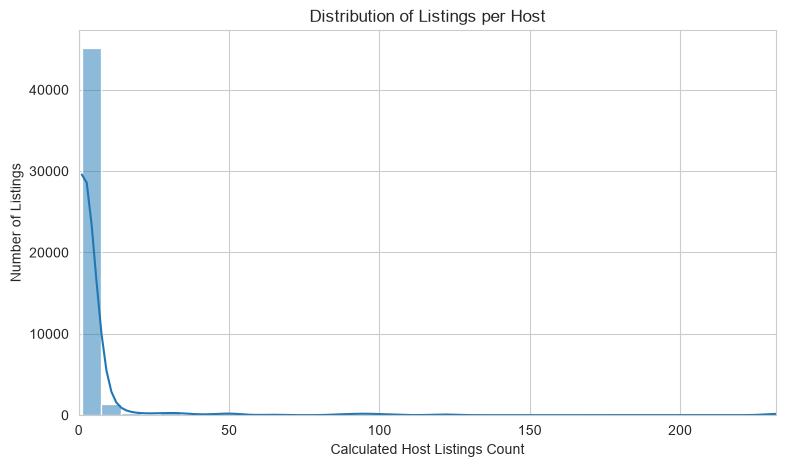

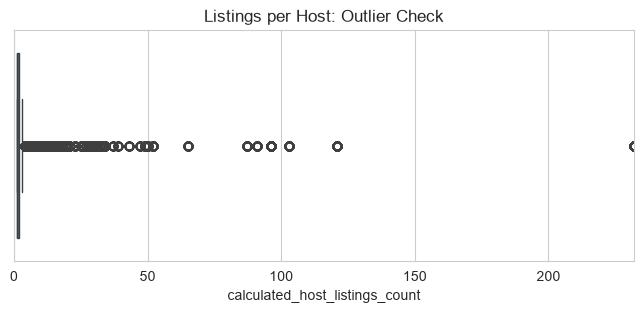

In [6]:

sns.set_style("whitegrid")

# ---------- 1. neighbourhood_group ----------
print(df["neighbourhood_group"].value_counts())

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="neighbourhood_group",
    order=df["neighbourhood_group"].value_counts().index
)
plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.xticks(rotation=30)
plt.show()


# ---------- 2. room_type ----------
print(df["room_type"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="room_type",
    order=df["room_type"].value_counts().index
)
plt.title("Distribution of Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)
plt.show()


# ---------- 3. price_per_night ----------
print(df["price_per_night"].describe())

plt.figure(figsize=(9, 5))
sns.histplot(df["price_per_night"], bins=50, kde=True)
plt.title("Distribution of Nightly Price")
plt.xlabel("Nightly Price")
plt.ylabel("Number of Listings")
plt.xlim(0, df["price_per_night"].quantile(0.99))  # hides extreme values for readability
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df["price_per_night"])
plt.title("Nightly Price: Outlier Check")
plt.xlim(0, df["price_per_night"].quantile(0.99))
plt.show()


# ---------- 4. minimum_nights ----------
print(df["minimum_nights"].describe())

plt.figure(figsize=(9, 5))
sns.histplot(df["minimum_nights"], bins=50, kde=True)
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.xlim(0, df["minimum_nights"].quantile(0.99))
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df["minimum_nights"])
plt.title("Minimum Nights: Outlier Check")
plt.xlim(0, df["minimum_nights"].quantile(0.99))
plt.show()


# ---------- 5. calculated_host_listings_count ----------
print(df["calculated_host_listings_count"].describe())

plt.figure(figsize=(9, 5))
sns.histplot(df["calculated_host_listings_count"], bins=50, kde=True)
plt.title("Distribution of Listings per Host")
plt.xlabel("Calculated Host Listings Count")
plt.ylabel("Number of Listings")
plt.xlim(0, df["calculated_host_listings_count"].quantile(0.99))
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df["calculated_host_listings_count"])
plt.title("Listings per Host: Outlier Check")
plt.xlim(0
         , df["calculated_host_listings_count"].quantile(0.99))
plt.show()

### findings : 
1. neighbourhood_group : manhattan has the max number of listings .

2. room_type : entirehome/apartment take the most number of offerings, meaning that is most preffered by the guests over private and shared rooms .

3. price_per_night : majority of the listings charge between 0 to 150 dollars with a peak around 40 - 50 dollars (prices are the most concentrated around that range). 
the prices after 160 are otuliers (that is they charge higher than 160 but are lesser to find) 

4. minimum_nights :

### bivariate analysis :

In [7]:

sns.set_style("whitegrid")

# Use this variable so you can easily switch to "price" if needed
target = "price_per_night"

# Keep plots readable by excluding the most extreme 1% of prices
plot_df = df[df[target] <= df[target].quantile(0.99)].copy()

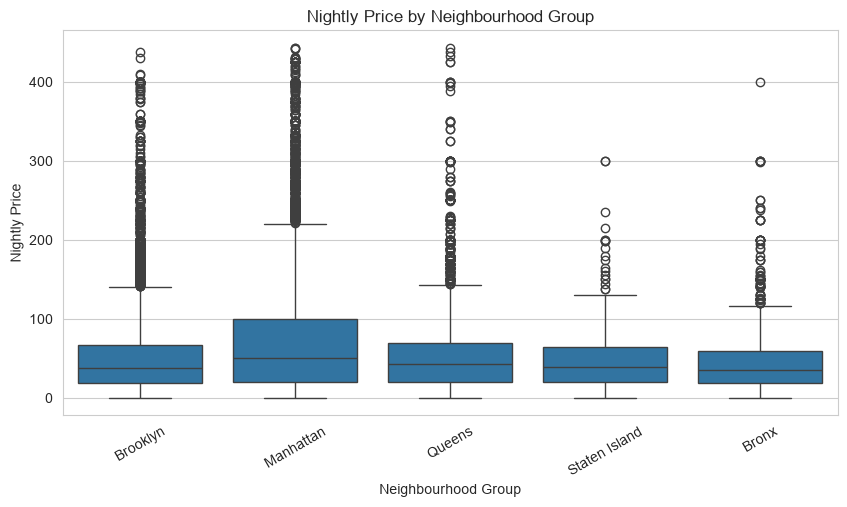

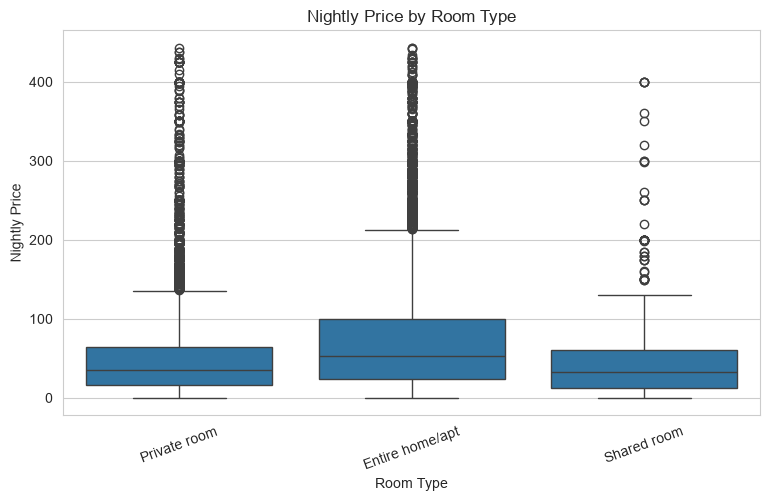

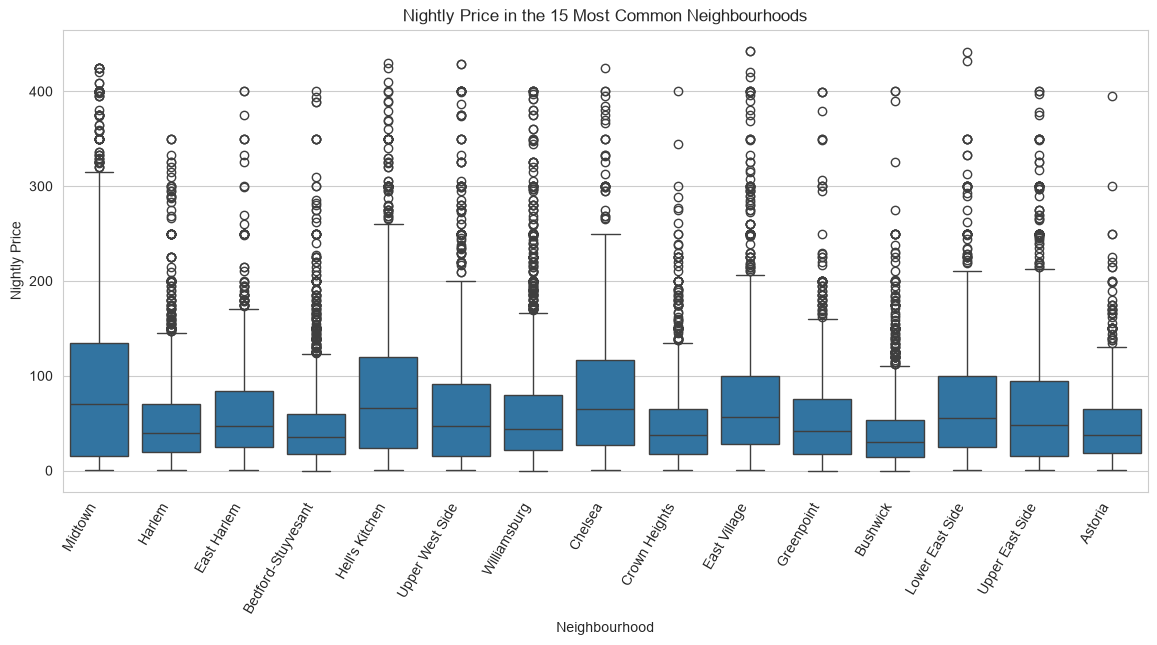

In [8]:
# 1. Neighbourhood group vs nightly price
plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x="neighbourhood_group", y=target)
plt.title("Nightly Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Nightly Price")
plt.xticks(rotation=30)
plt.show()


# 2. Room type vs nightly price
plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="room_type", y=target)
plt.title("Nightly Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Nightly Price")
plt.xticks(rotation=20)
plt.show()


# 3. Top 15 neighbourhoods vs nightly price
top_neighbourhoods = df["neighbourhood"].value_counts().head(15).index
neighbourhood_df = plot_df[plot_df["neighbourhood"].isin(top_neighbourhoods)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=neighbourhood_df, x="neighbourhood", y=target)
plt.title("Nightly Price in the 15 Most Common Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Nightly Price")
plt.xticks(rotation=60, ha="right")
plt.show()

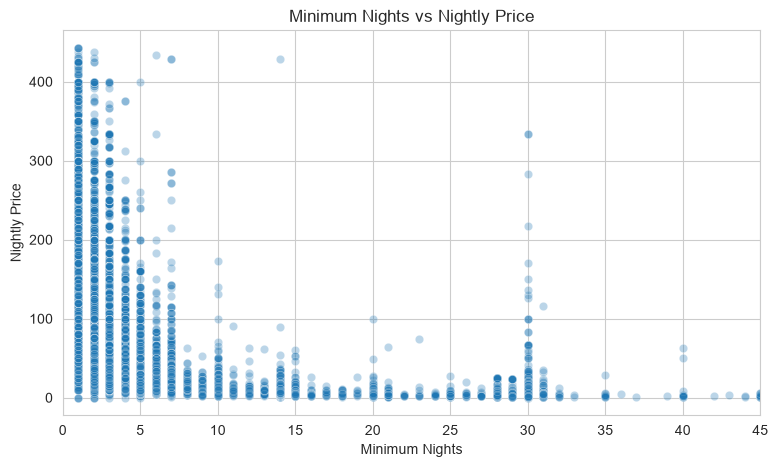

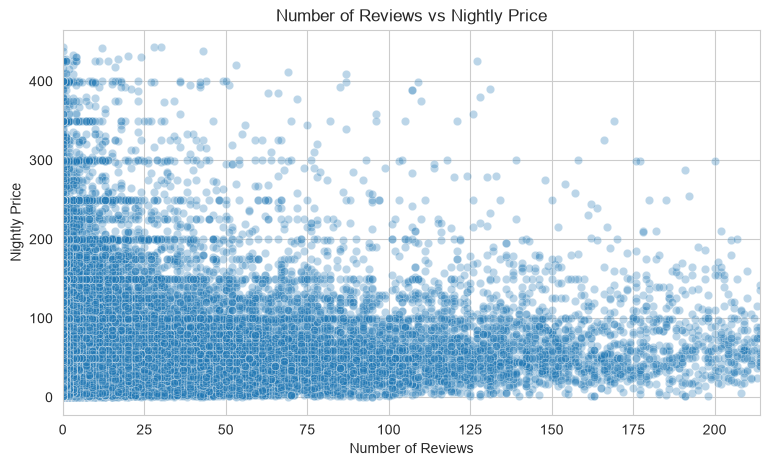

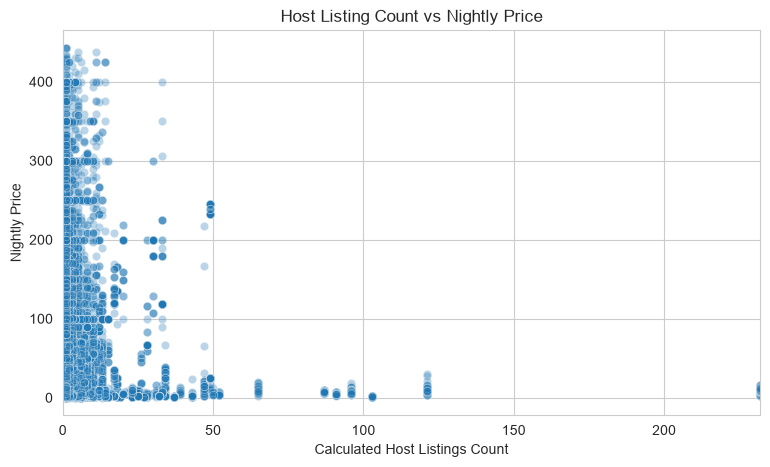

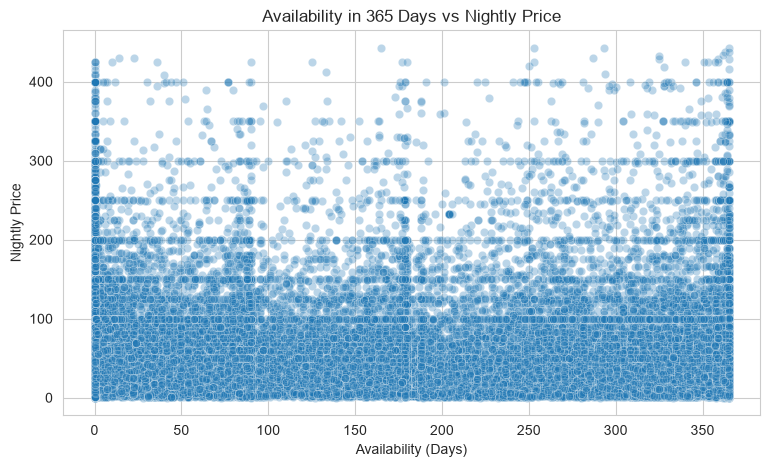

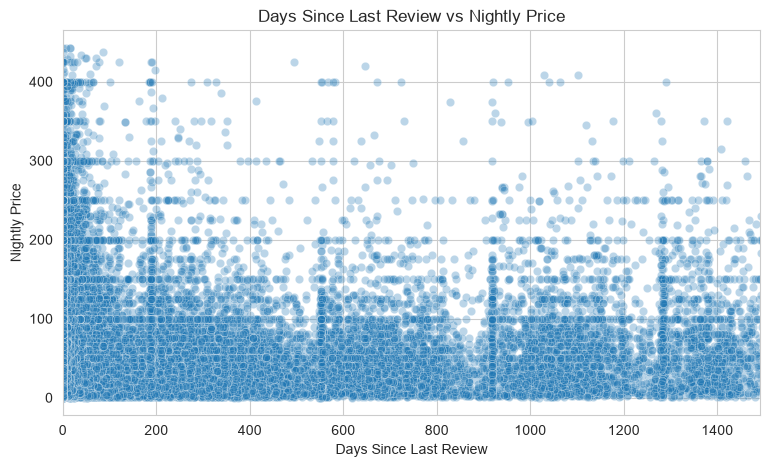

In [9]:
# 4. Minimum nights vs nightly price
plt.figure(figsize=(9, 5))
sns.scatterplot(data=plot_df, x="minimum_nights", y=target, alpha=0.3)
plt.title("Minimum Nights vs Nightly Price")
plt.xlabel("Minimum Nights")
plt.ylabel("Nightly Price")
plt.xlim(0, plot_df["minimum_nights"].quantile(0.99))
plt.show()


# 5. Number of reviews vs nightly price
plt.figure(figsize=(9, 5))
sns.scatterplot(data=plot_df, x="number_of_reviews", y=target, alpha=0.3)
plt.title("Number of Reviews vs Nightly Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Nightly Price")
plt.xlim(0, plot_df["number_of_reviews"].quantile(0.99))
plt.show()


# 6. Host listing count vs nightly price
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=plot_df,
    x="calculated_host_listings_count",
    y=target,
    alpha=0.3
)
plt.title("Host Listing Count vs Nightly Price")
plt.xlabel("Calculated Host Listings Count")
plt.ylabel("Nightly Price")
plt.xlim(0, plot_df["calculated_host_listings_count"].quantile(0.99))
plt.show()


# 7. Availability over 365 days vs nightly price
plt.figure(figsize=(9, 5))
sns.scatterplot(data=plot_df, x="availability_365", y=target, alpha=0.3)
plt.title("Availability in 365 Days vs Nightly Price")
plt.xlabel("Availability (Days)")
plt.ylabel("Nightly Price")
plt.show()


# 8. Days since last review vs nightly price
plt.figure(figsize=(9, 5))
sns.scatterplot(data=plot_df, x="days_since_last_review", y=target, alpha=0.3)
plt.title("Days Since Last Review vs Nightly Price")
plt.xlabel("Days Since Last Review")
plt.ylabel("Nightly Price")
plt.xlim(0, plot_df["days_since_last_review"].quantile(0.99))
plt.show()

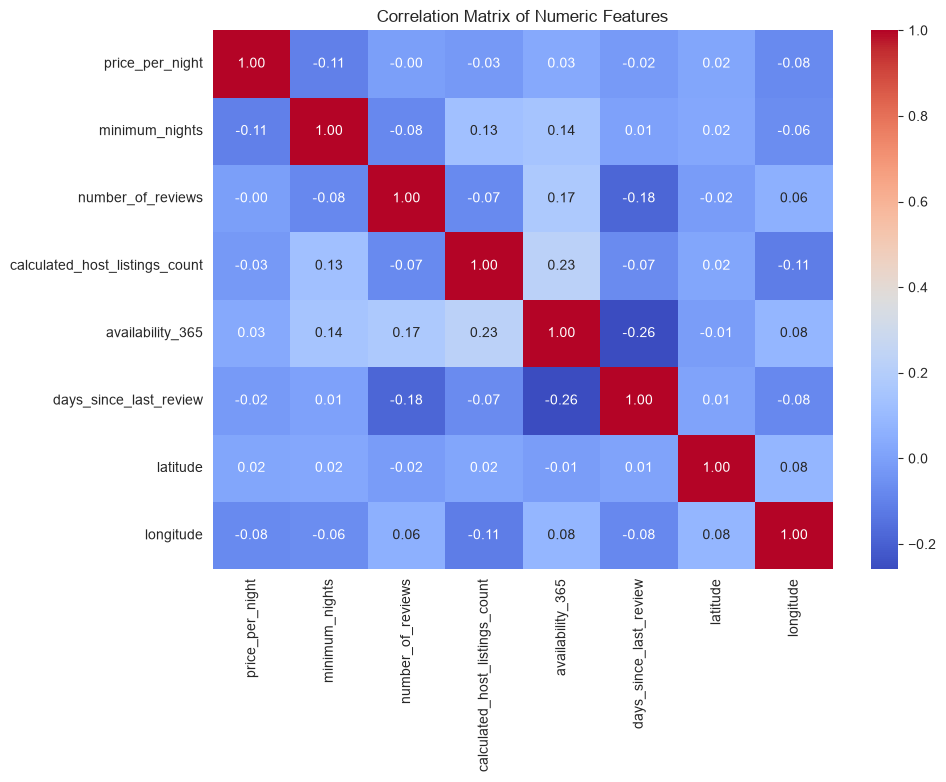

In [10]:
numeric_columns = [
    target,
    "minimum_nights",
    "number_of_reviews",
    "calculated_host_listings_count",
    "availability_365",
    "days_since_last_review",
    "latitude",
    "longitude"
]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [19]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Keep only required, complete rows
map_df = df[["latitude", "longitude", "price_per_night"]].dropna().copy()

# Calculate Q1 and Q3 price thresholds
low_cutoff = map_df["price_per_night"].quantile(0.33)
high_cutoff = map_df["price_per_night"].quantile(0.67)

print(f"Cheap-price threshold: up to ${low_cutoff:,.2f}")
print(f"Medium-price range: above ${low_cutoff:,.2f} to ${high_cutoff:,.2f}")
print(f"Expensive-price threshold: above ${high_cutoff:,.2f}")

# Create labels that show the thresholds in the map legend
cheap_label = f"Cheap (≤ ${low_cutoff:,.0f})"
medium_label = f"Medium (${low_cutoff:,.0f}–${high_cutoff:,.0f})"
expensive_label = f"Expensive (> ${high_cutoff:,.0f})"

# Categorize listings using Q1 and Q3
map_df["price_category"] = pd.cut(
    map_df["price_per_night"],
    bins=[-float("inf"), low_cutoff, high_cutoff, float("inf")],
    labels=[cheap_label, medium_label, expensive_label]
)

# Plot listings on an OpenStreetMap basemap of New York
fig = px.scatter_map(
    map_df,
    lat="latitude",
    lon="longitude",
    color="price_category",
    category_orders={
        "price_category": [cheap_label, medium_label, expensive_label]
    },
    color_discrete_map={
        cheap_label: "green",
        medium_label: "orange",
        expensive_label: "red"
    },
    hover_data={"price_per_night": True},
    zoom=10,
    center={"lat": 40.7128, "lon": -74.0060},
    height=700,
    opacity=0.55,
    title=(
        "New York Airbnb Listings by Nightly Price Category "
        f"(Q1 = ${low_cutoff:,.0f}, Q3 = ${high_cutoff:,.0f})"
    )
)

fig.update_layout(
    map_style="open-street-map",
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

# Coordinate range of the listings
lat_min = map_df["latitude"].min()
lat_max = map_df["latitude"].max()
lon_min = map_df["longitude"].min()
lon_max = map_df["longitude"].max()

# Five horizontal latitude lines and five vertical longitude lines
latitude_lines = np.linspace(lat_min, lat_max, 5)
longitude_lines = np.linspace(lon_min, lon_max, 5)

grid_lines = []

# Horizontal latitude lines
for lat in latitude_lines:
    grid_lines.append(
        go.Scattermap(
            lat=[lat, lat],
            lon=[lon_min, lon_max],
            mode="lines",
            line=dict(color="rgba(0, 0, 0, 0.35)", width=1),
            hoverinfo="skip",
            showlegend=False
        )
    )

# Vertical longitude lines
for lon in longitude_lines:
    grid_lines.append(
        go.Scattermap(
            lat=[lat_min, lat_max],
            lon=[lon, lon],
            mode="lines",
            line=dict(color="rgba(0, 0, 0, 0.35)", width=1),
            hoverinfo="skip",
            showlegend=False
        )
    )

# Add latitude and longitude grid lines
fig.add_traces(grid_lines)

fig.show()

Cheap-price threshold: up to $26.67
Medium-price range: above $26.67 to $66.63
Expensive-price threshold: above $66.63


In [18]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Keep only required, complete rows
map_df = df[["latitude", "longitude", "price_per_night"]].dropna().copy()

# Calculate Q1 and Q3 price thresholds
low_cutoff = map_df["price_per_night"].quantile(0.25)
high_cutoff = map_df["price_per_night"].quantile(0.75)

print(f"Cheap-price threshold: up to ${low_cutoff:,.2f}")
print(f"Medium-price range: above ${low_cutoff:,.2f} to ${high_cutoff:,.2f}")
print(f"Expensive-price threshold: above ${high_cutoff:,.2f}")

# Create labels that show the thresholds in the map legend
cheap_label = f"Cheap (≤ ${low_cutoff:,.0f})"
medium_label = f"Medium (${low_cutoff:,.0f}–${high_cutoff:,.0f})"
expensive_label = f"Expensive (> ${high_cutoff:,.0f})"

# Categorize listings using Q1 and Q3
map_df["price_category"] = pd.cut(
    map_df["price_per_night"],
    bins=[-float("inf"), low_cutoff, high_cutoff, float("inf")],
    labels=[cheap_label, medium_label, expensive_label]
)

# Plot listings on an OpenStreetMap basemap of New York
fig = px.scatter_map(
    map_df,
    lat="latitude",
    lon="longitude",
    color="price_category",
    category_orders={
        "price_category": [cheap_label, medium_label, expensive_label]
    },
    color_discrete_map={
        cheap_label: "green",
        medium_label: "orange",
        expensive_label: "red"
    },
    hover_data={"price_per_night": True},
    zoom=10,
    center={"lat": 40.7128, "lon": -74.0060},
    height=700,
    opacity=0.55,
    title=(
        "New York Airbnb Listings by Nightly Price Category "
        f"(Q1 = ${low_cutoff:,.0f}, Q3 = ${high_cutoff:,.0f})"
    )
)

fig.update_layout(
    map_style="open-street-map",
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

# Coordinate range of the listings
lat_min = map_df["latitude"].min()
lat_max = map_df["latitude"].max()
lon_min = map_df["longitude"].min()
lon_max = map_df["longitude"].max()

# Five horizontal latitude lines and five vertical longitude lines
latitude_lines = np.linspace(lat_min, lat_max, 5)
longitude_lines = np.linspace(lon_min, lon_max, 5)

grid_lines = []

# Horizontal latitude lines
for lat in latitude_lines:
    grid_lines.append(
        go.Scattermap(
            lat=[lat, lat],
            lon=[lon_min, lon_max],
            mode="lines",
            line=dict(color="rgba(0, 0, 0, 0.35)", width=1),
            hoverinfo="skip",
            showlegend=False
        )
    )

# Vertical longitude lines
for lon in longitude_lines:
    grid_lines.append(
        go.Scattermap(
            lat=[lat_min, lat_max],
            lon=[lon, lon],
            mode="lines",
            line=dict(color="rgba(0, 0, 0, 0.35)", width=1),
            hoverinfo="skip",
            showlegend=False
        )
    )

# Add latitude and longitude grid lines
fig.add_traces(grid_lines)

fig.show()

Cheap-price threshold: up to $20.00
Medium-price range: above $20.00 to $81.50
Expensive-price threshold: above $81.50


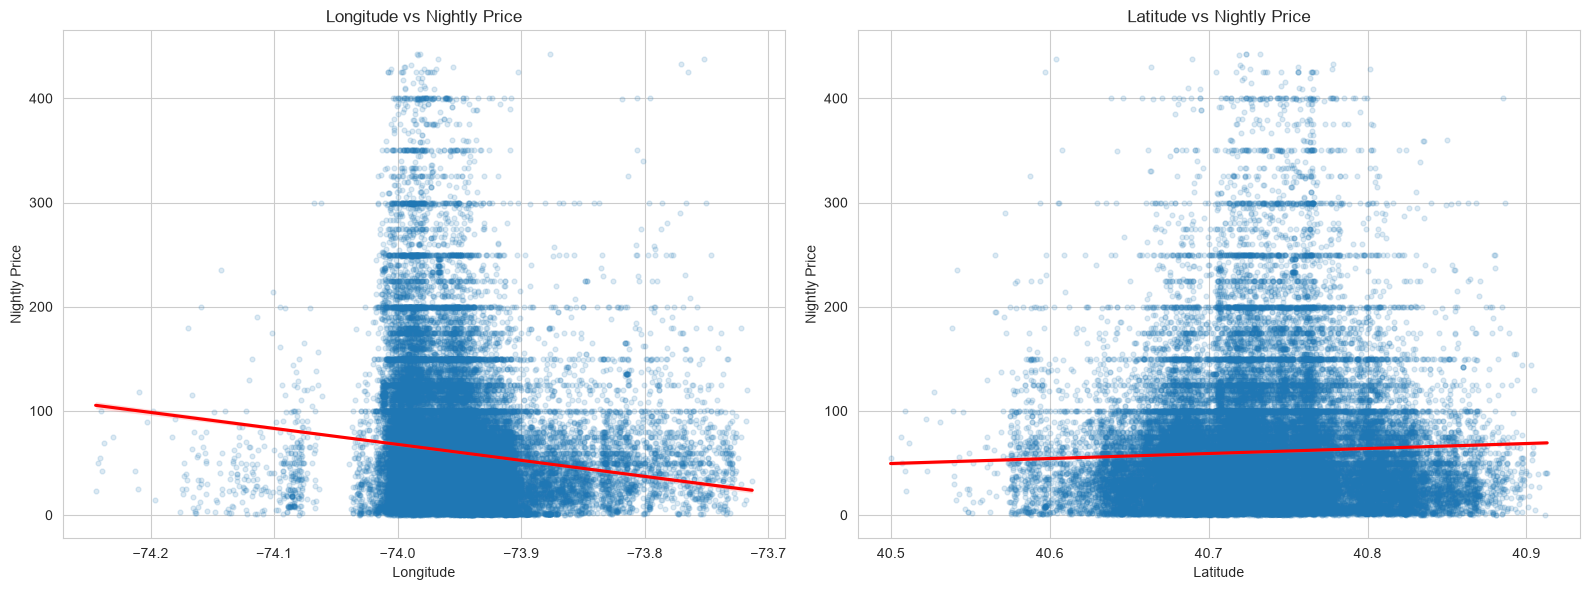

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only complete rows and hide the most extreme 1% of prices
geo_df = df[["latitude", "longitude", "price_per_night"]].dropna().copy()
geo_df = geo_df[
    geo_df["price_per_night"] <= geo_df["price_per_night"].quantile(0.99)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Longitude vs price
sns.regplot(
    data=geo_df,
    x="longitude",
    y="price_per_night",
    scatter_kws={"alpha": 0.15, "s": 12},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].set_title("Longitude vs Nightly Price")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Nightly Price")

# Latitude vs price
sns.regplot(
    data=geo_df,
    x="latitude",
    y="price_per_night",
    scatter_kws={"alpha": 0.15, "s": 12},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_title("Latitude vs Nightly Price")
axes[1].set_xlabel("Latitude")
axes[1].set_ylabel("Nightly Price")

plt.tight_layout()
plt.show()

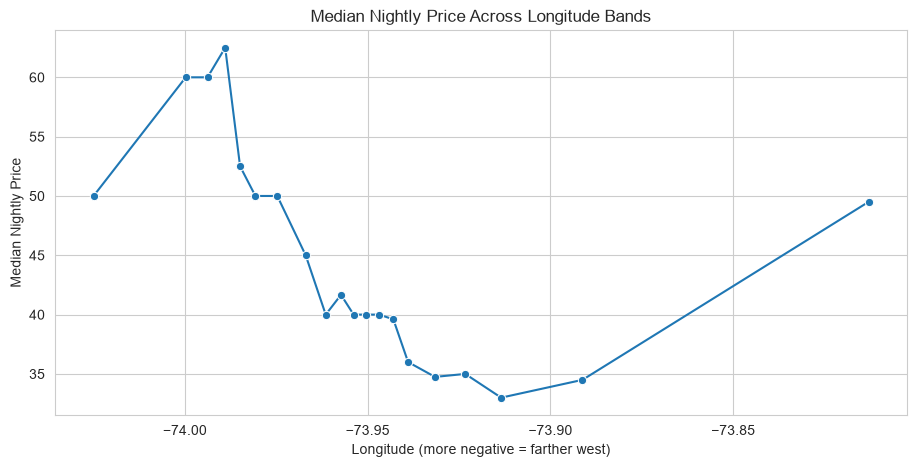

In [14]:
geo_df["longitude_band"] = pd.qcut(
    geo_df["longitude"],
    q=20,
    duplicates="drop"
)

longitude_summary = (
    geo_df.groupby("longitude_band", observed=True)
    .agg(
        median_price=("price_per_night", "median"),
        average_longitude=("longitude", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=longitude_summary,
    x="average_longitude",
    y="median_price",
    marker="o"
)

plt.title("Median Nightly Price Across Longitude Bands")
plt.xlabel("Longitude (more negative = farther west)")
plt.ylabel("Median Nightly Price")
plt.show()